In [1]:
import sys
sys.path.append('/workspaces/EstructuraDatos_2026_01')

In [2]:
from Goodrich.ch08.linked_binary_tree import *

In [3]:
!pip install matplotlib

Defaulting to user installation because normal site-packages is not writeable

[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


In [4]:
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

In [ ]:
def construir(L):
    LB = LinkedBinaryTree()

    if len(L) == 0:
        return LB

    root = LB._add_root(L[0])

    def ramas(nodo_actual, posicion_en_lista):
        indiiz = 2 * posicion_en_lista + 1
        indider = 2 * posicion_en_lista + 2


        if indiiz < len(L):
            l = LB._add_left(nodo_actual, L[indiiz])
            ramas(l, indiiz)

        if indider < len(L):
            r = LB._add_right(nodo_actual, L[indider])
            ramas(r, indider)

    ramas(root, 0)

    return LB

    

In [6]:
def dibujar(T):
    fig, ax = plt.subplots(figsize=(10, 6))
    ax.axis('off')

    posiciones = {}
    elementos  = {}
    padres     = {}

    colores_lineas = ['red', 'green', 'orange', 'purple', 'gray', 'pink', 'blue']
    color_arista   = {}
    contador       = [0]

    def calcular_xy(p, x, y, espacio): 

        if p is None or p.element() is None:
            return 
        
        nodo = p._node
        posiciones[nodo] = (x, y)
        elementos[nodo]  = p.element()
        padre = T.parent(p)
        if padre is not None:
          padres[nodo] = padre._node   
        else:
          padres[nodo] = None


        if padres[nodo] is not None:
            color_arista[nodo] = colores_lineas[contador[0] % len(colores_lineas)]
            contador[0] += 1

        calcular_xy(T.left(p),  x - espacio, y - 1, espacio / 2)
        calcular_xy(T.right(p), x + espacio, y - 1, espacio / 2)

    calcular_xy(T.root(), x=0, y=0, espacio=4)


    for nodo, (x, y) in posiciones.items():
        nodo_padre = padres[nodo]
        if nodo_padre is not None:
            xp, yp = posiciones[nodo_padre]
            color = color_arista[nodo]
            ax.plot([x, xp], [y, yp], color=color, linewidth=2, zorder=1)


    for nodo, (x, y) in posiciones.items():
        color = color_arista.get(nodo, 'black')
        ax.plot(x, y, 'o', markersize=8, color=color, zorder=2)
        ax.text(x + 0.15, y, str(elementos[nodo]),
                ha='left', va='center',
                fontsize=11, color=color, fontweight='bold')

    plt.tight_layout()
    plt.show()

/tmp/ipykernel_766/651578007.py:53: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


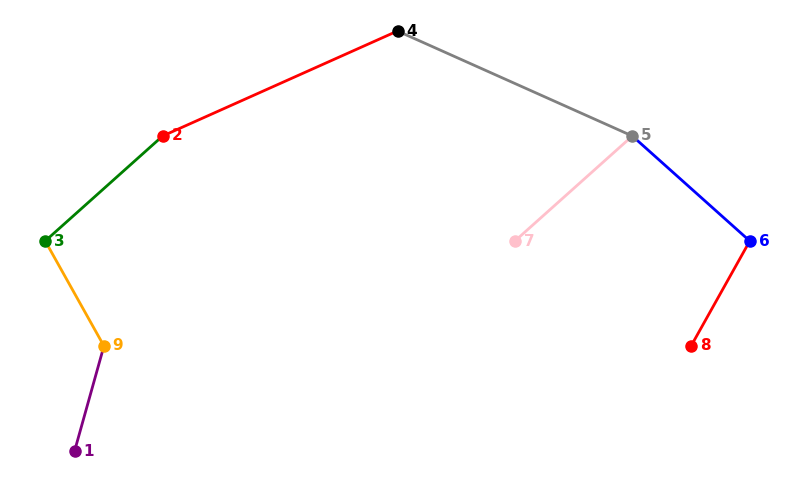

In [7]:
dibujar(construir([4, 2, 5, 3, None, 7, 6, None, 9, None, None, None, None, 8, None, None, None, 1]))

In [8]:
def intercambiar_raices(T):
    if T.is_empty():
        return T

    r = T.root()

    left = T.left(r)
    right = T.right(r)

   
    r._node._left, r._node._right = r._node._right, r._node._left

    return T

In [9]:
def pegar_en_hoja(T1, T2):
    if T1.is_empty():
        return

    def buscar_hoja(p):
        if T1.is_leaf(p):
            return p
        
        if T1.left(p):
            res = buscar_hoja(T1.left(p))
            if res:
                return res
        
        if T1.right(p):
            res = buscar_hoja(T1.right(p))
            if res:
                return res

    hoja = buscar_hoja(T1.root())

    if hoja is None:
        return

    if T1.left(hoja) is None:
        T1._attach(hoja, T2, LinkedBinaryTree())
    else:
        T1._attach(hoja, LinkedBinaryTree(), T2)

In [10]:
def agregar_izquierda(T1, T2):
    if T1.is_empty():
        return

    def buscar_hoja(p):
        if T1.is_leaf(p):
            return p
        
        if T1.left(p):
            res = buscar_hoja(T1.left(p))
            if res:
                return res
        
        if T1.right(p):
            res = buscar_hoja(T1.right(p))
            if res:
                return res

    hoja = buscar_hoja(T1.root())

    if hoja is None:
        return

   
    if T1.left(hoja) is None:
        T1._attach(hoja, T2, LinkedBinaryTree())
    else:
        print("La hoja ya tiene hijo izquierdo")

/tmp/ipykernel_766/651578007.py:53: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


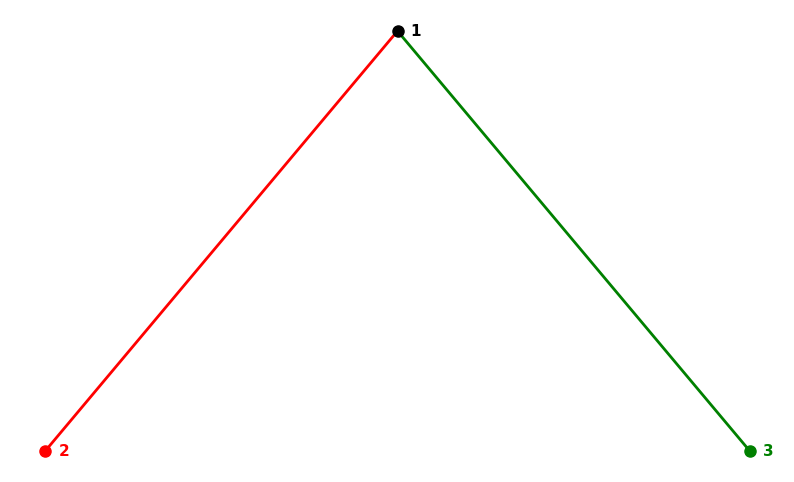

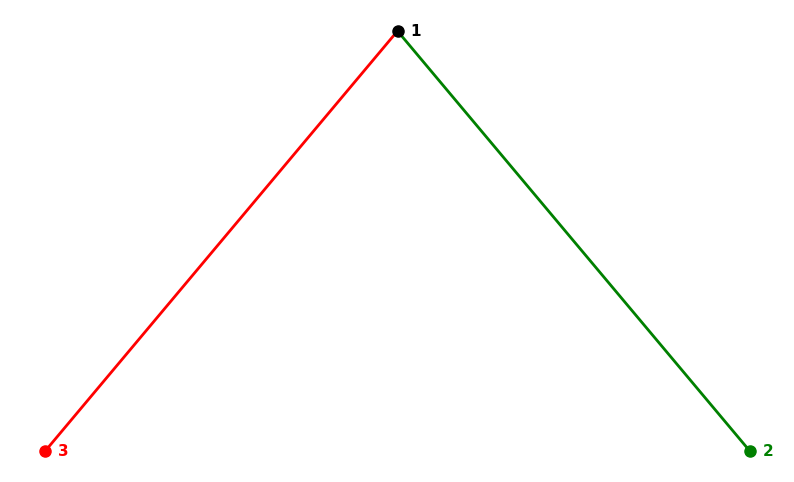

In [11]:
L = [1, 2, 3]
T = construir(L)

dibujar(T)             
intercambiar_raices(T)
dibujar(T)      

/tmp/ipykernel_766/651578007.py:53: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


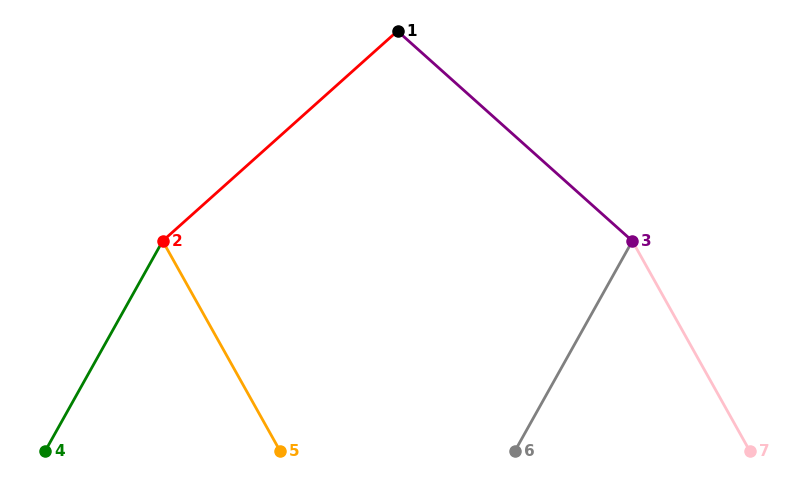

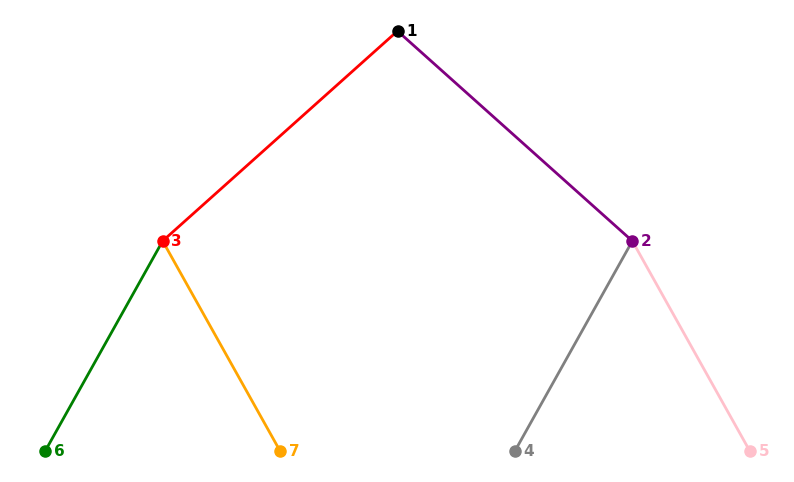

In [12]:
L = [1, 2, 3, 4, 5, 6, 7]
T = construir(L)

dibujar(T)
intercambiar_raices(T)
dibujar(T)

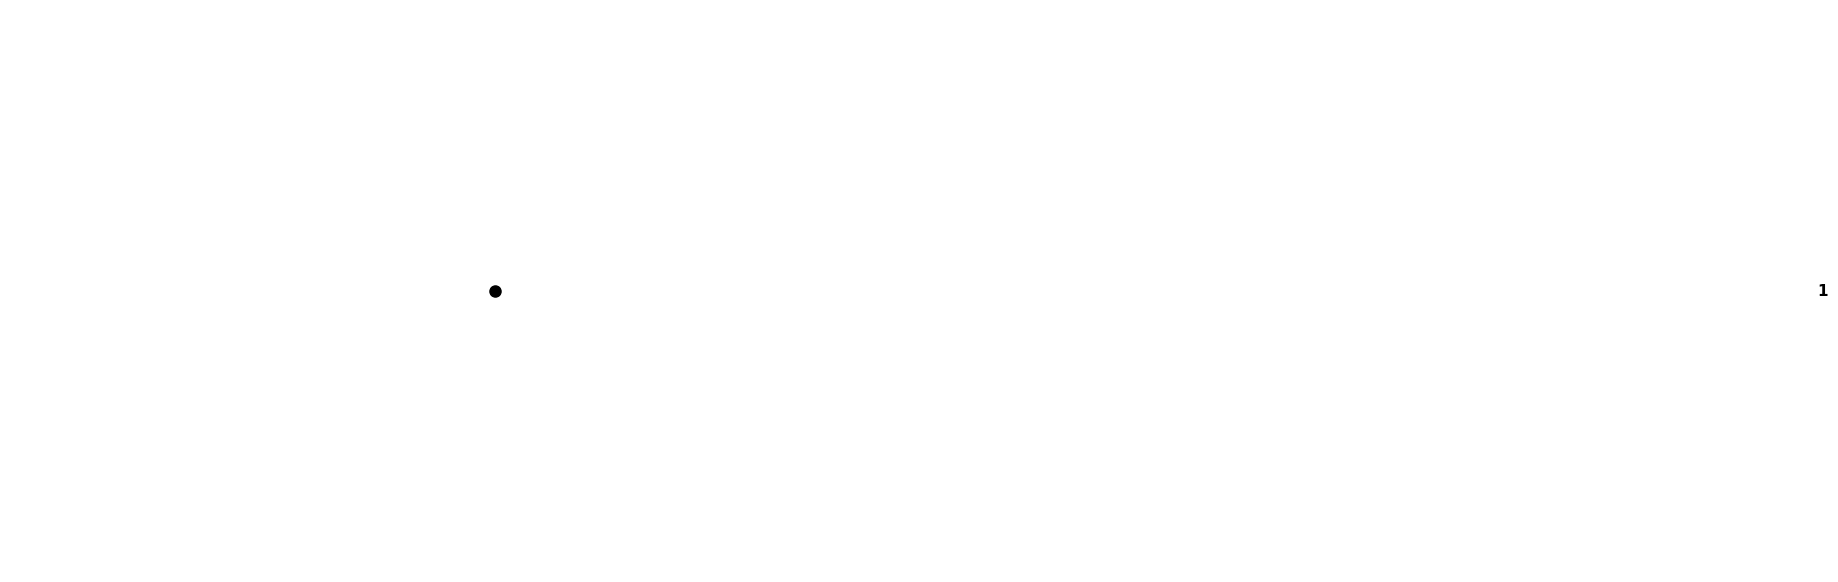

In [13]:
L = [1]
T = construir(L)

intercambiar_raices(T)
dibujar(T)

/tmp/ipykernel_766/651578007.py:53: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


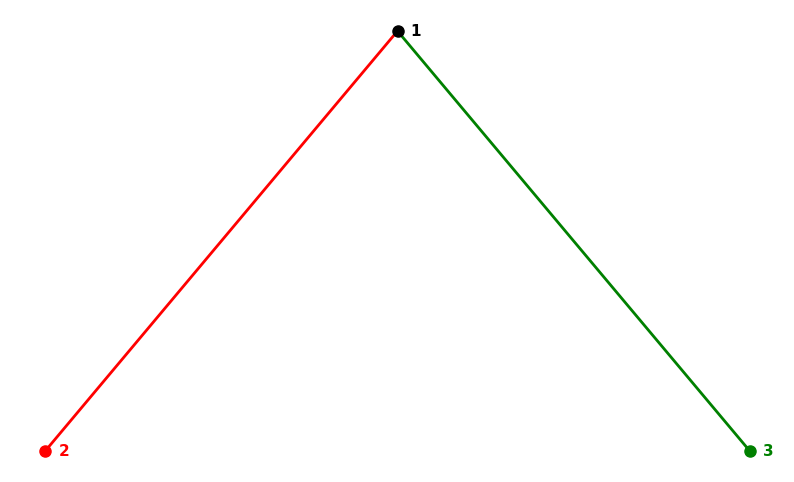

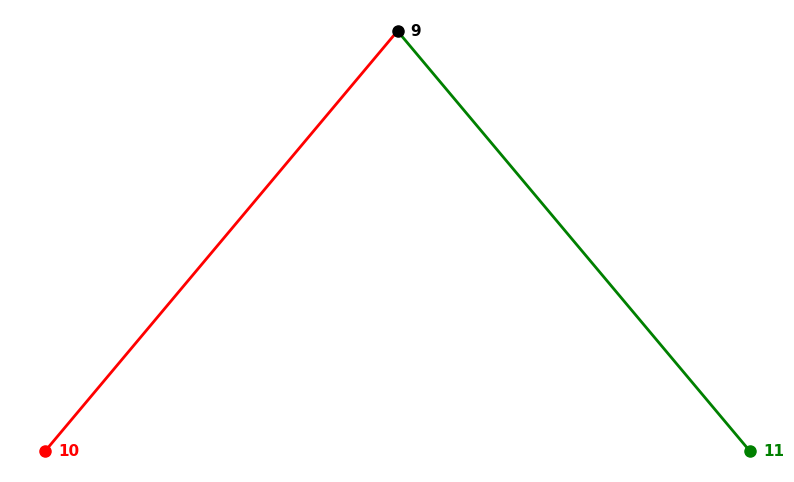

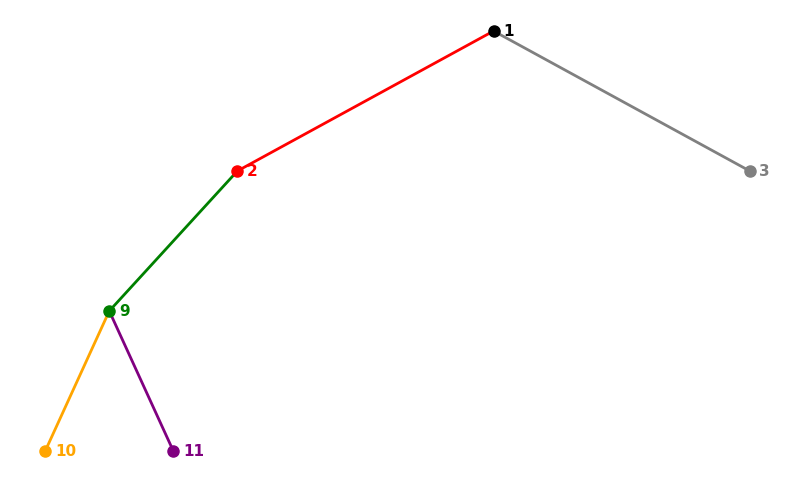

In [14]:
T1 = construir([1, 2, 3])
T2 = construir([9, 10, 11])

dibujar(T1)
dibujar(T2)

pegar_en_hoja(T1, T2)
dibujar(T1)

/tmp/ipykernel_766/651578007.py:53: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


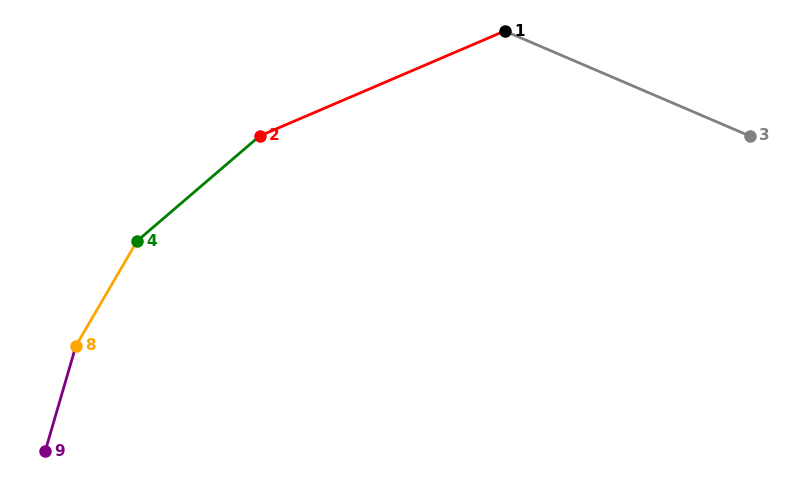

In [15]:
T1 = construir([1, 2, 3, 4, None, None, None])
T2 = construir([8, 9])

pegar_en_hoja(T1, T2)
dibujar(T1)

/tmp/ipykernel_766/651578007.py:53: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


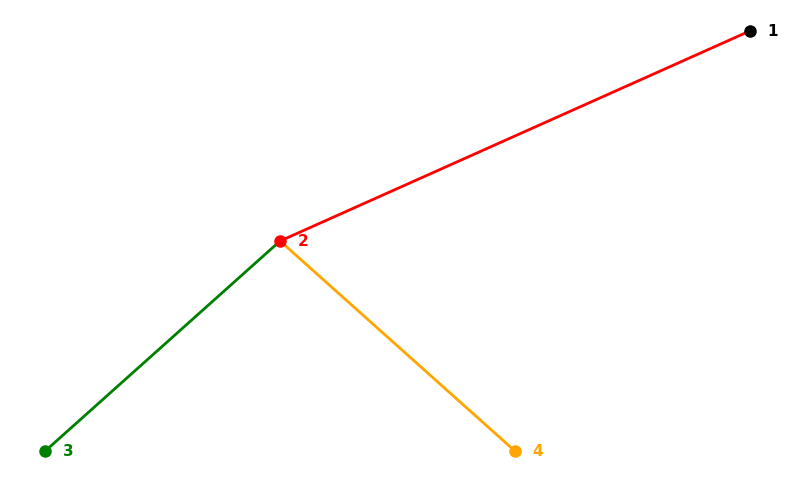

In [16]:
T1 = construir([1])
T2 = construir([2, 3, 4])

pegar_en_hoja(T1, T2)
dibujar(T1)

/tmp/ipykernel_766/651578007.py:53: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


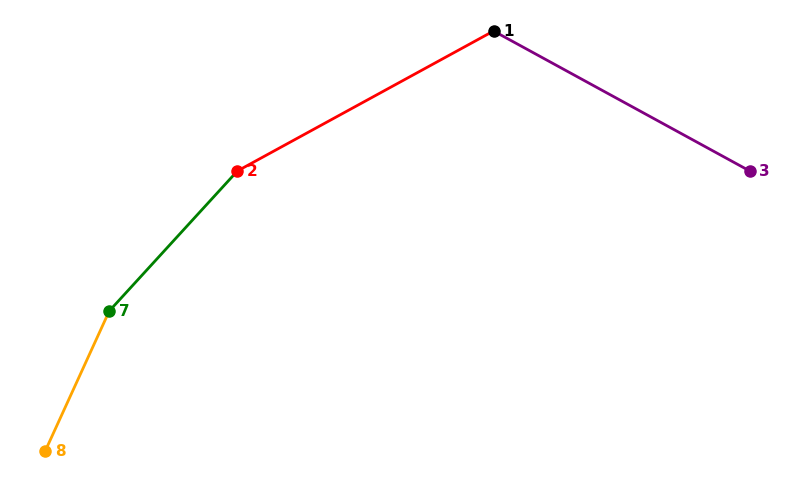

In [17]:
T1 = construir([1, 2, 3])
T2 = construir([7, 8])

agregar_izquierda(T1, T2)
dibujar(T1)

In [18]:
T = construir([10, 20, 30, 40, 50])       

/tmp/ipykernel_766/651578007.py:53: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


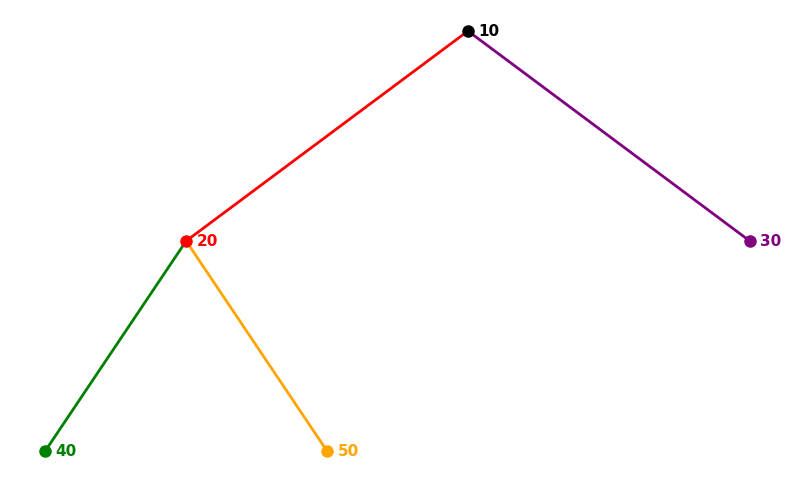

In [19]:
dibujar(T)

In [20]:
intercambiar_raices(T)

/tmp/ipykernel_766/651578007.py:53: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


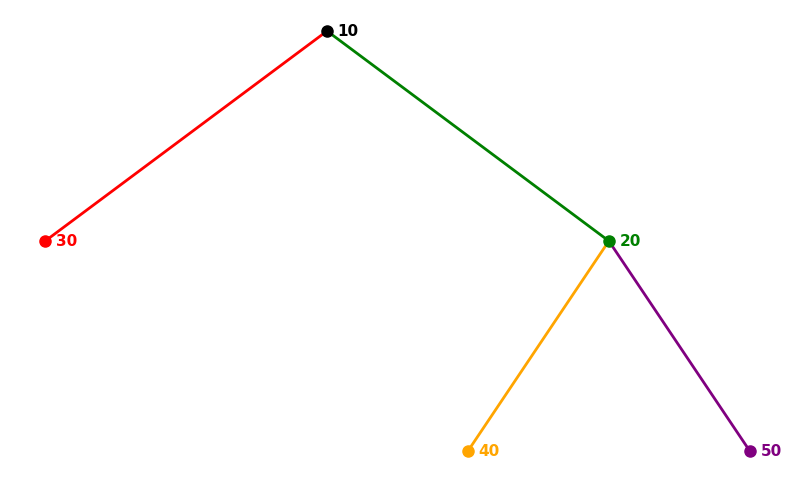

In [21]:
dibujar(T)

In [22]:
T2 = construir([99, 100])

/tmp/ipykernel_766/651578007.py:53: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


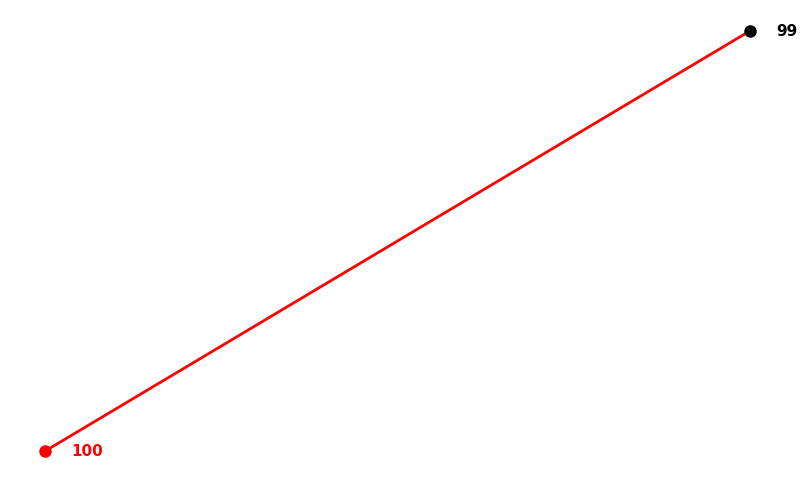

In [23]:
dibujar(T2)

In [24]:
pegar_en_hoja(T, T2)

/tmp/ipykernel_766/651578007.py:53: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


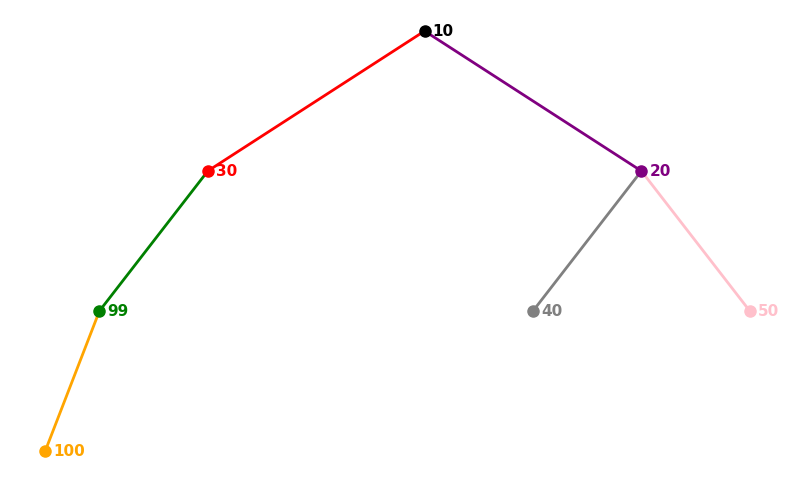

In [25]:
dibujar(T)

In [26]:
T1 = construir([1, 2, 3, 4, 5, 6, 7])
T2 = construir([8, 9, 10])
T3 = construir([11, 12])

In [27]:
pegar_en_hoja(T1, T2)

/tmp/ipykernel_766/651578007.py:53: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


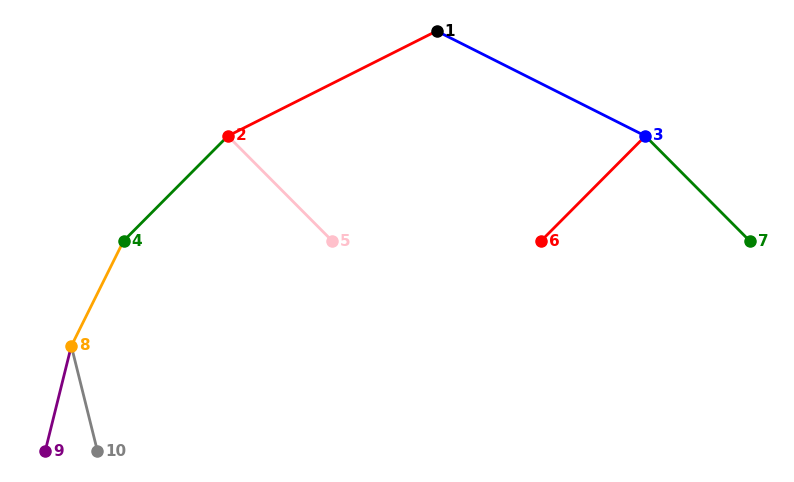

In [28]:
dibujar(T1)

In [29]:
agregar_izquierda(T1, T3)

/tmp/ipykernel_766/651578007.py:53: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


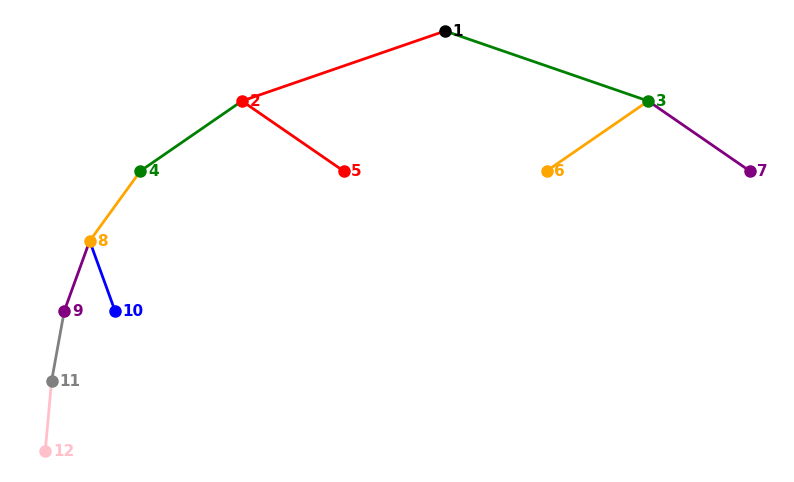

In [30]:
dibujar(T1)

In [31]:
T1 = construir([])
T2 = construir([1, 2])

pegar_en_hoja(T1, T2)

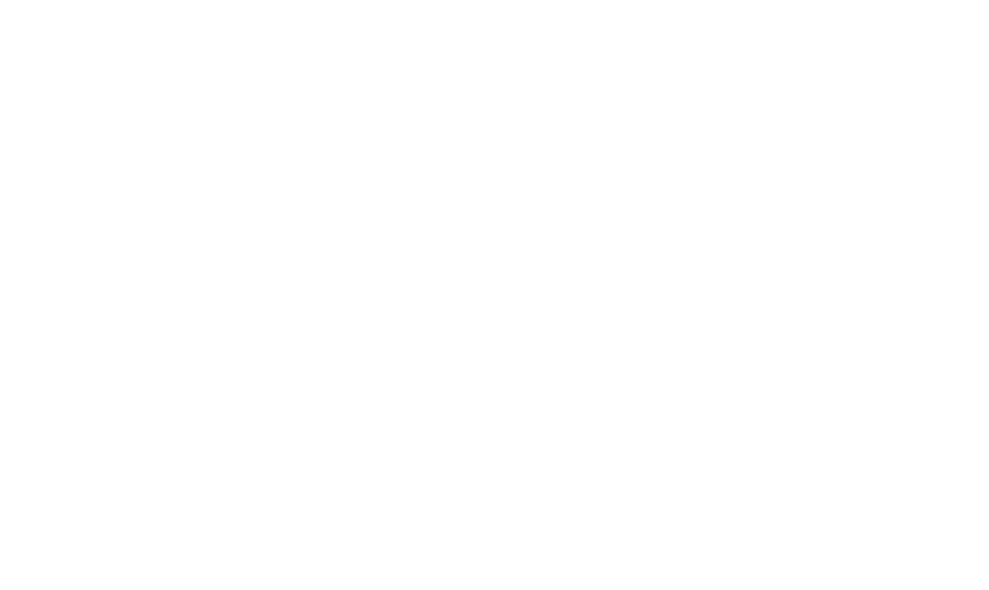

In [32]:
dibujar(T1)